# Implicit regularized RBSDE: max-RMSE and initial-value convergence

This notebook studies only the smooth regularization approximation of the American-put reflected BSDE. The regularization width is

$$
\varepsilon_{\Delta t}=1\,\Delta t_{\mathrm{obs}}^{\alpha},
\qquad
\alpha\in\{0.2,\,0.375,\,0.5,\,0.75,\,1\}.
$$

The left panel reports convergence of the maximum RMSE over all observation dates. The right panel reports the corresponding initial values $Y_0^\varepsilon$ together with the American-put CRR reference price.


In [1]:
from dataclasses import dataclass
from typing import Literal
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, logsumexp

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "axes.grid": True,
    "grid.linestyle": ":",
})


## Configuration

The coefficient of $\varepsilon_{\Delta t}$ is fixed globally at $1$. The experiment varies only its power $\alpha$.


In [2]:
ImplicitSolver = Literal["picard", "bisection", "newton"]

EPSILON_CONSTANT = 1.0
EPSILON_POWERS = (0.2, 3 / 8, 0.5, 0.75, 1.0)
SLOPE_POWERS = EPSILON_POWERS[:-1]


@dataclass(frozen=True)
class ModelParams:
    """Market, contract, and binomial-tree parameters."""

    S0: float = 100.0
    K: float = 100.0
    T: float = 1.0
    r: float = 0.02
    sigma: float = 0.2
    N_fine: int = 2**15
    N_reference: int = 2**15


@dataclass(frozen=True)
class ExperimentConfig:
    """Regularized-RBSDE convergence experiment."""

    model: ModelParams
    implicit_solver: ImplicitSolver = "bisection"
    N_obs_grid: tuple[int, ...] = (2**8, 2**9, 2**10, 2**11, 2**12, 2**13)
    epsilon_powers: tuple[float, ...] = EPSILON_POWERS


SOLVER_LABELS = {
    "picard": "Picard iteration",
    "bisection": "bisection method",
    "newton": "Newton's method",
}

LINE_STYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
MARKERS = ["o", "s", "^", "D", "v"]


def epsilon_value(dt_obs: float, epsilon_power: float) -> float:
    """Evaluate epsilon = 1 * dt_obs**alpha."""
    return EPSILON_CONSTANT * dt_obs**epsilon_power


def format_power(epsilon_power: float) -> str:
    """Format alpha compactly and consistently for tables and legends."""
    return f"{epsilon_power:g}"


def show_slope(epsilon_power: float) -> bool:
    """Fit and display slopes for alpha in {0.2, 0.375, 0.5, 0.75}."""
    return any(np.isclose(epsilon_power, power) for power in SLOPE_POWERS)


## American-put CRR reference and binomial-grid helpers


In [3]:
def binomial_probabilities(m: int, q: float) -> np.ndarray:
    """Probability mass for the number of up moves over m fine-tree steps."""
    ell = np.arange(m + 1)
    if q <= 0.0:
        probabilities = np.zeros(m + 1)
        probabilities[0] = 1.0
        return probabilities
    if q >= 1.0:
        probabilities = np.zeros(m + 1)
        probabilities[-1] = 1.0
        return probabilities

    log_probabilities = (
        gammaln(m + 1)
        - gammaln(ell + 1)
        - gammaln(m - ell + 1)
        + ell * np.log(q)
        + (m - ell) * np.log1p(-q)
    )
    return np.exp(log_probabilities - logsumexp(log_probabilities))


def multi_step_conditional_expectation(
    Y_next: np.ndarray,
    probabilities: np.ndarray,
) -> np.ndarray:
    """Compute E[Y_next | current node] across m skipped fine steps."""
    return np.correlate(Y_next, probabilities, mode="valid")


def observation_indices(N_fine: int, N_obs: int) -> np.ndarray:
    """Map a sparse observation grid to integer levels of the fine tree."""
    indices = np.rint(np.linspace(0, N_fine, N_obs + 1)).astype(int)
    indices[0] = 0
    indices[-1] = N_fine
    if np.any(np.diff(indices) <= 0):
        raise ValueError("Observation grid has repeated indices.")
    return indices



## Smooth regularization generator


In [4]:
def smooth_cutoff(x: np.ndarray) -> np.ndarray:
    """Smooth switch: one for x <= 0, zero for x >= 1."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    out[x <= 0.0] = 1.0
    transition = (x > 0.0) & (x < 1.0)

    def bump(t: np.ndarray) -> np.ndarray:
        return np.exp(-1.0 / t)

    left = bump(x[transition])
    right = bump(1.0 - x[transition])
    out[transition] = right / (left + right)
    return out


def phi(x: np.ndarray, epsilon: float) -> np.ndarray:
    """Scale the smooth cutoff by the regularization width epsilon."""
    if epsilon <= 0.0:
        raise ValueError("epsilon must be positive.")
    return smooth_cutoff(x / epsilon)


def regularized_generator(
    S: np.ndarray,
    Y: np.ndarray,
    obstacle: np.ndarray,
    epsilon: float,
    model: ModelParams,
) -> np.ndarray:
    """Regularized American-put reflected-BSDE generator."""
    correction = model.r * model.K * (S <= model.K).astype(float)
    return -model.r * Y + phi(Y - obstacle, epsilon) * correction


def implicit_residual(
    Y: np.ndarray,
    base: np.ndarray,
    S: np.ndarray,
    obstacle: np.ndarray,
    epsilon: float,
    model: ModelParams,
    dt: float,
) -> np.ndarray:
    """Residual of Y = base + dt*f(S,Y)."""
    return Y - base - dt * regularized_generator(S, Y, obstacle, epsilon, model)


## Implicit solvers


In [5]:
def picard(
    base: np.ndarray,
    S: np.ndarray,
    obstacle: np.ndarray,
    epsilon: float,
    model: ModelParams,
    dt: float,
    tol: float = 1e-8,
    max_iter: int = 500,
) -> np.ndarray:
    """Fixed-point iteration for one regularized implicit update."""
    Y = base.copy()
    for _ in range(max_iter):
        Y_new = base + dt * regularized_generator(S, Y, obstacle, epsilon, model)
        if np.max(np.abs(Y_new - Y)) < tol:
            return Y_new
        Y = Y_new
    raise RuntimeError("Picard iteration did not converge within max_iter steps.")


def bisection(
    base: np.ndarray,
    S: np.ndarray,
    obstacle: np.ndarray,
    epsilon: float,
    model: ModelParams,
    dt: float,
    tol: float = 1e-12,
    max_iter: int = 500,
) -> np.ndarray:
    """Nodewise bisection for one regularized implicit update."""
    A = 1.0 + model.r * dt
    B = dt * model.r * model.K * (S <= model.K)
    y0 = base / A
    y1 = (base + B) / A

    fixed_y0 = (B == 0.0) | (y0 >= obstacle + epsilon)
    fixed_y1 = (~fixed_y0) & (y1 <= obstacle)
    unresolved = ~(fixed_y0 | fixed_y1)

    Y = np.empty_like(base)
    Y[fixed_y0] = y0[fixed_y0]
    Y[fixed_y1] = y1[fixed_y1]
    if not np.any(unresolved):
        return Y

    base_active = base[unresolved]
    B_active = B[unresolved]
    obstacle_active = obstacle[unresolved]
    lo = np.maximum(y0[unresolved], obstacle_active)
    hi = np.minimum(y1[unresolved], obstacle_active + epsilon)

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        residual = (
            A * mid
            - base_active
            - B_active * phi(mid - obstacle_active, epsilon)
        )
        lo = np.where(residual <= 0.0, mid, lo)
        hi = np.where(residual > 0.0, mid, hi)
        if np.max(hi - lo) < tol:
            break

    Y[unresolved] = 0.5 * (lo + hi)
    return Y


def newton(
    base: np.ndarray,
    S: np.ndarray,
    obstacle: np.ndarray,
    epsilon: float,
    model: ModelParams,
    dt: float,
    tol: float = 1e-8,
    max_iter: int = 200,
) -> np.ndarray:
    """Nodewise Newton method with a centered finite-difference derivative."""
    Y = base.copy()
    for _ in range(max_iter):
        residual = implicit_residual(Y, base, S, obstacle, epsilon, model, dt)
        h = 1e-5 * np.maximum(1.0, np.abs(Y))
        derivative = (
            implicit_residual(Y + h, base, S, obstacle, epsilon, model, dt)
            - implicit_residual(Y - h, base, S, obstacle, epsilon, model, dt)
        ) / (2.0 * h)
        derivative = np.where(np.abs(derivative) < 1e-14, 1e-14, derivative)
        Y_new = Y - residual / derivative
        if np.max(np.abs(Y_new - Y)) < tol:
            return Y_new
        Y = Y_new
    raise RuntimeError("Newton iteration did not converge within max_iter steps.")


def solve_implicit_update(
    base: np.ndarray,
    S: np.ndarray,
    obstacle: np.ndarray,
    epsilon: float,
    model: ModelParams,
    dt: float,
    implicit_solver: ImplicitSolver,
) -> np.ndarray:
    """Dispatch one regularized implicit update to the chosen solver."""
    arguments = dict(
        base=base,
        S=S,
        obstacle=obstacle,
        epsilon=epsilon,
        model=model,
        dt=dt,
    )
    if implicit_solver == "picard":
        return picard(**arguments)
    if implicit_solver == "bisection":
        return bisection(**arguments)
    if implicit_solver == "newton":
        return newton(**arguments)
    raise ValueError(f"Unknown implicit_solver={implicit_solver!r}.")


## Sparse-observation regularized RBSDE solver and RMSE


In [6]:
def streaming_rmse_sweep(
    model: ModelParams,
    epsilon_powers: tuple[float, ...],
    N_obs_grid: np.ndarray,
    implicit_solver: ImplicitSolver,
    verbose: bool = True,
) -> tuple[dict[float, np.ndarray], dict[float, np.ndarray], float]:
    """Run all approximations during one memory-bounded CRR rollback.

    Only the current CRR level and one active value vector per parameter pair
    are retained. This avoids materializing every tree level and every
    binomial weight vector.
    """
    if model.N_fine != model.N_reference:
        raise ValueError("This comparison assumes N_fine == N_reference.")

    N = model.N_fine
    dt_fine = model.T / N
    u = np.exp(model.sigma * np.sqrt(dt_fine))
    d = 1.0 / u
    q = (np.exp(model.r * dt_fine) - d) / (u - d)
    if not (0.0 <= q <= 1.0):
        raise ValueError(f"Invalid risk-neutral probability q={q:.6f}.")
    disc = np.exp(-model.r * dt_fine)

    N_obs_values = tuple(int(N_obs) for N_obs in N_obs_grid)
    observation_grids = {
        N_obs: observation_indices(N, N_obs) for N_obs in N_obs_values
    }
    next_positions = {
        N_obs: len(indices) - 2 for N_obs, indices in observation_grids.items()
    }

    gaps = {
        int(gap)
        for indices in observation_grids.values()
        for gap in np.diff(indices)
    }
    transition_probabilities = {
        gap: binomial_probabilities(gap, q) for gap in gaps
    }

    j = np.arange(N + 1)
    S_terminal = model.S0 * u**j * d ** (N - j)
    terminal_values = np.maximum(model.K - S_terminal, 0.0)
    reference_values = terminal_values

    approximation_values = {
        (epsilon_power, N_obs): terminal_values
        for epsilon_power in epsilon_powers
        for N_obs in N_obs_values
    }
    time_rmse = {
        (epsilon_power, N_obs): np.empty(N_obs + 1)
        for epsilon_power in epsilon_powers
        for N_obs in N_obs_values
    }
    for errors in time_rmse.values():
        errors[-1] = 0.0

    start = time.perf_counter()
    progress_stride = max(1, N // 10)
    for n in range(N - 1, -1, -1):
        reference_values = disc * (
            (1.0 - q) * reference_values[:-1] + q * reference_values[1:]
        )
        j_now = np.arange(n + 1)
        S_now = model.S0 * u**j_now * d ** (n - j_now)
        obstacle = np.maximum(model.K - S_now, 0.0)
        reference_values = np.maximum(reference_values, obstacle)

        active_grids = []
        for N_obs, indices in observation_grids.items():
            k = next_positions[N_obs]
            if k >= 0 and n == int(indices[k]):
                active_grids.append((N_obs, k))
                next_positions[N_obs] = k - 1

        if active_grids:
            state_probabilities = binomial_probabilities(n, q)
            for N_obs, k in active_grids:
                indices = observation_grids[N_obs]
                gap = int(indices[k + 1] - indices[k])
                dt_obs = gap * dt_fine
                probabilities = transition_probabilities[gap]

                for epsilon_power in epsilon_powers:
                    key = (epsilon_power, N_obs)
                    base = multi_step_conditional_expectation(
                        approximation_values[key], probabilities
                    )
                    Y = solve_implicit_update(
                        base=base,
                        S=S_now,
                        obstacle=obstacle,
                        epsilon=epsilon_value(dt_obs, epsilon_power),
                        model=model,
                        dt=dt_obs,
                        implicit_solver=implicit_solver,
                    )
                    approximation_values[key] = Y
                    difference = Y - reference_values
                    time_rmse[key][k] = np.sqrt(
                        np.sum(state_probabilities * difference**2)
                    )

        if verbose and (n == 0 or (N - n) % progress_stride == 0):
            completed = 100.0 * (N - n) / N
            print(
                f"Streaming rollback: {completed:5.1f}% complete, "
                f"elapsed = {time.perf_counter() - start:.2f}s"
            )

    if any(position >= 0 for position in next_positions.values()):
        raise RuntimeError("Not all observation levels were processed.")

    max_rmse_by_power = {
        epsilon_power: np.array([
            np.max(time_rmse[(epsilon_power, N_obs)])
            for N_obs in N_obs_values
        ])
        for epsilon_power in epsilon_powers
    }
    Y0_by_power = {
        epsilon_power: np.array([
            approximation_values[(epsilon_power, N_obs)][0]
            for N_obs in N_obs_values
        ])
        for epsilon_power in epsilon_powers
    }
    return max_rmse_by_power, Y0_by_power, float(reference_values[0])


## Convergence experiment and two-panel plot

Dashed fitted lines and reported slopes are included for $\alpha=0.2$, $0.375$, $0.5$, and $0.75$. The $\alpha=1$ curve is shown without a fitted slope.


In [7]:
def run_convergence_experiment(
    experiment: ExperimentConfig,
    verbose: bool = True,
) -> dict:
    """Sweep epsilon powers at fixed coefficient 1."""
    model = experiment.model
    N_obs_grid = np.asarray(experiment.N_obs_grid, dtype=int)
    dt_obs_vals = model.T / N_obs_grid
    max_rmse_by_power, Y0_by_power, crr_reference_price = streaming_rmse_sweep(
        model=model,
        epsilon_powers=experiment.epsilon_powers,
        N_obs_grid=N_obs_grid,
        implicit_solver=experiment.implicit_solver,
        verbose=verbose,
    )

    slopes = {}
    intercepts = {}

    for epsilon_power in experiment.epsilon_powers:
        max_rmse = max_rmse_by_power[epsilon_power]
        Y0_epsilon = Y0_by_power[epsilon_power]

        if verbose:
            print("\n" + "=" * 78)
            print(
                "Regularized RBSDE with "
                f"epsilon = {EPSILON_CONSTANT:g} * dt_obs^{format_power(epsilon_power)}"
            )
            print(f"Implicit solver: {SOLVER_LABELS[experiment.implicit_solver]}")
            print(f"CRR reference price: {crr_reference_price:.10f}")
            print("=" * 78)

        for index, N_obs in enumerate(N_obs_grid):
            if verbose:
                print(
                    f"alpha = {format_power(epsilon_power):>5}, "
                    f"N_obs = {int(N_obs):>5}, "
                    f"max RMSE = {max_rmse[index]:.8e}, "
                    f"Y0^epsilon = {Y0_epsilon[index]:.10f}"
                )

        if show_slope(epsilon_power):
            valid = max_rmse > 0.0
            slope, intercept = np.polyfit(
                np.log(dt_obs_vals[valid]),
                np.log(max_rmse[valid]),
                deg=1,
            )
            slopes[epsilon_power] = float(slope)
            intercepts[epsilon_power] = float(intercept)
            if verbose:
                print(f"Fitted max-RMSE slope: {slope:.6f}")

    return {
        "experiment": experiment,
        "N_obs_grid": N_obs_grid,
        "dt_obs_vals": dt_obs_vals,
        "max_rmse": max_rmse_by_power,
        "Y0_epsilon": Y0_by_power,
        "slopes": slopes,
        "intercepts": intercepts,
        "crr_reference_price": crr_reference_price,
    }


def plot_convergence(result: dict):
    """Plot max-RMSE convergence and initial values against the CRR price."""
    experiment = result["experiment"]
    dt_obs_vals = result["dt_obs_vals"]
    log_dt_vals = np.log(dt_obs_vals)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), dpi=200)

    for index, epsilon_power in enumerate(experiment.epsilon_powers):
        max_rmse = result["max_rmse"][epsilon_power]
        Y0_epsilon = result["Y0_epsilon"][epsilon_power]
        valid = max_rmse > 0.0
        line_style = LINE_STYLES[index % len(LINE_STYLES)]
        marker = MARKERS[index % len(MARKERS)]

        slope = result["slopes"].get(epsilon_power)
        if slope is None:
            convergence_label = fr"$\alpha={format_power(epsilon_power)}$"
        else:
            convergence_label = (
                fr"$\alpha={format_power(epsilon_power)}$, slope={slope:.3f}"
            )

        convergence_line, = axes[0].plot(
            log_dt_vals[valid],
            np.log(max_rmse[valid]),
            linestyle=line_style,
            marker=marker,
            label=convergence_label,
        )

        if slope is not None:
            intercept = result["intercepts"][epsilon_power]
            order = np.argsort(log_dt_vals)
            axes[0].plot(
                log_dt_vals[order],
                intercept + slope * log_dt_vals[order],
                color=convergence_line.get_color(),
                linestyle="--",
                linewidth=1.3,
                alpha=0.65,
                label="_nolegend_",
            )

        axes[1].plot(
            log_dt_vals,
            Y0_epsilon,
            color=convergence_line.get_color(),
            linestyle=line_style,
            marker=marker,
            label=fr"$\alpha={format_power(epsilon_power)}$",
        )

    crr_reference_price = result["crr_reference_price"]
    axes[1].axhline(
        crr_reference_price,
        color="black",
        linestyle="--",
        linewidth=1.4,
        label=fr"CRR reference = {crr_reference_price:.6f}",
    )

    axes[0].set_xlabel(r"$\log(\Delta t_{\mathrm{obs}})$")
    axes[0].set_ylabel("log(max RMSE)")
    # axes[0].set_title("Max RMSE convergence")
    axes[0].legend()

    axes[1].set_xlabel(r"$\log(\Delta t_{\mathrm{obs}})$")
    axes[1].set_ylabel(r"$Y_0^\varepsilon$")
    # axes[1].set_title(r"Initial values $Y_0^\varepsilon$ and CRR benchmark")
    axes[1].legend()

    # solver_label = SOLVER_LABELS[experiment.implicit_solver]
    # fig.suptitle(
    #     fr"Regularized RBSDE: $\varepsilon=1\,\Delta t_{{\mathrm{{obs}}}}^\alpha$ "
    #     f"({solver_label})"
    # )
    fig.tight_layout()

    plt.show()
    return fig, axes


## Base parameters


In [8]:
base_model = ModelParams(
    S0=100.0,
    K=100.0,
    T=1.0,
    r=0.02,
    sigma=0.2,
    N_fine=2**15,
    N_reference=2**15,
)

regularized_experiment = ExperimentConfig(
    model=base_model,
    implicit_solver="bisection",
    N_obs_grid=(2**10, 2**11, 2**12, 2**13, 2**14, 2**15),
    epsilon_powers=(0.2, 3 / 8, 0.5, 0.75, 1.0),
)


## Regularized RBSDE example


Streaming rollback:  10.0% complete, elapsed = 152.71s


Streaming rollback:  20.0% complete, elapsed = 286.05s


Streaming rollback:  30.0% complete, elapsed = 421.78s


Streaming rollback:  40.0% complete, elapsed = 531.02s


Streaming rollback:  50.0% complete, elapsed = 624.12s


Streaming rollback:  60.0% complete, elapsed = 689.49s


Streaming rollback:  70.0% complete, elapsed = 732.45s


Streaming rollback:  80.0% complete, elapsed = 761.92s


Streaming rollback:  90.0% complete, elapsed = 784.84s


Streaming rollback: 100.0% complete, elapsed = 803.63s
Streaming rollback: 100.0% complete, elapsed = 803.63s

Regularized RBSDE with epsilon = 1 * dt_obs^0.2
Implicit solver: bisection method
CRR reference price: 7.1107752267
alpha =   0.2, N_obs =  1024, max RMSE = 4.68850898e-02, Y0^epsilon = 7.1503107748
alpha =   0.2, N_obs =  2048, max RMSE = 4.19160942e-02, Y0^epsilon = 7.1462139460
alpha =   0.2, N_obs =  4096, max RMSE = 3.73596859e-02, Y0^epsilon = 7.1424399197
alpha =   0.2, N_obs =  8192, max RMSE = 3.32222106e-02, Y0^epsilon = 7.1390018872
alpha =   0.2, N_obs = 16384, max RMSE = 2.94889690e-02, Y0^epsilon = 7.1358914873
alpha =   0.2, N_obs = 32768, max RMSE = 2.61349379e-02, Y0^epsilon = 7.1330901014
Fitted max-RMSE slope: 0.168773

Regularized RBSDE with epsilon = 1 * dt_obs^0.375
Implicit solver: bisection method
CRR reference price: 7.1107752267
alpha = 0.375, N_obs =  1024, max RMSE = 1.61074081e-02, Y0^epsilon = 7.1246138642
alpha = 0.375, N_obs =  2048, max RMSE = 

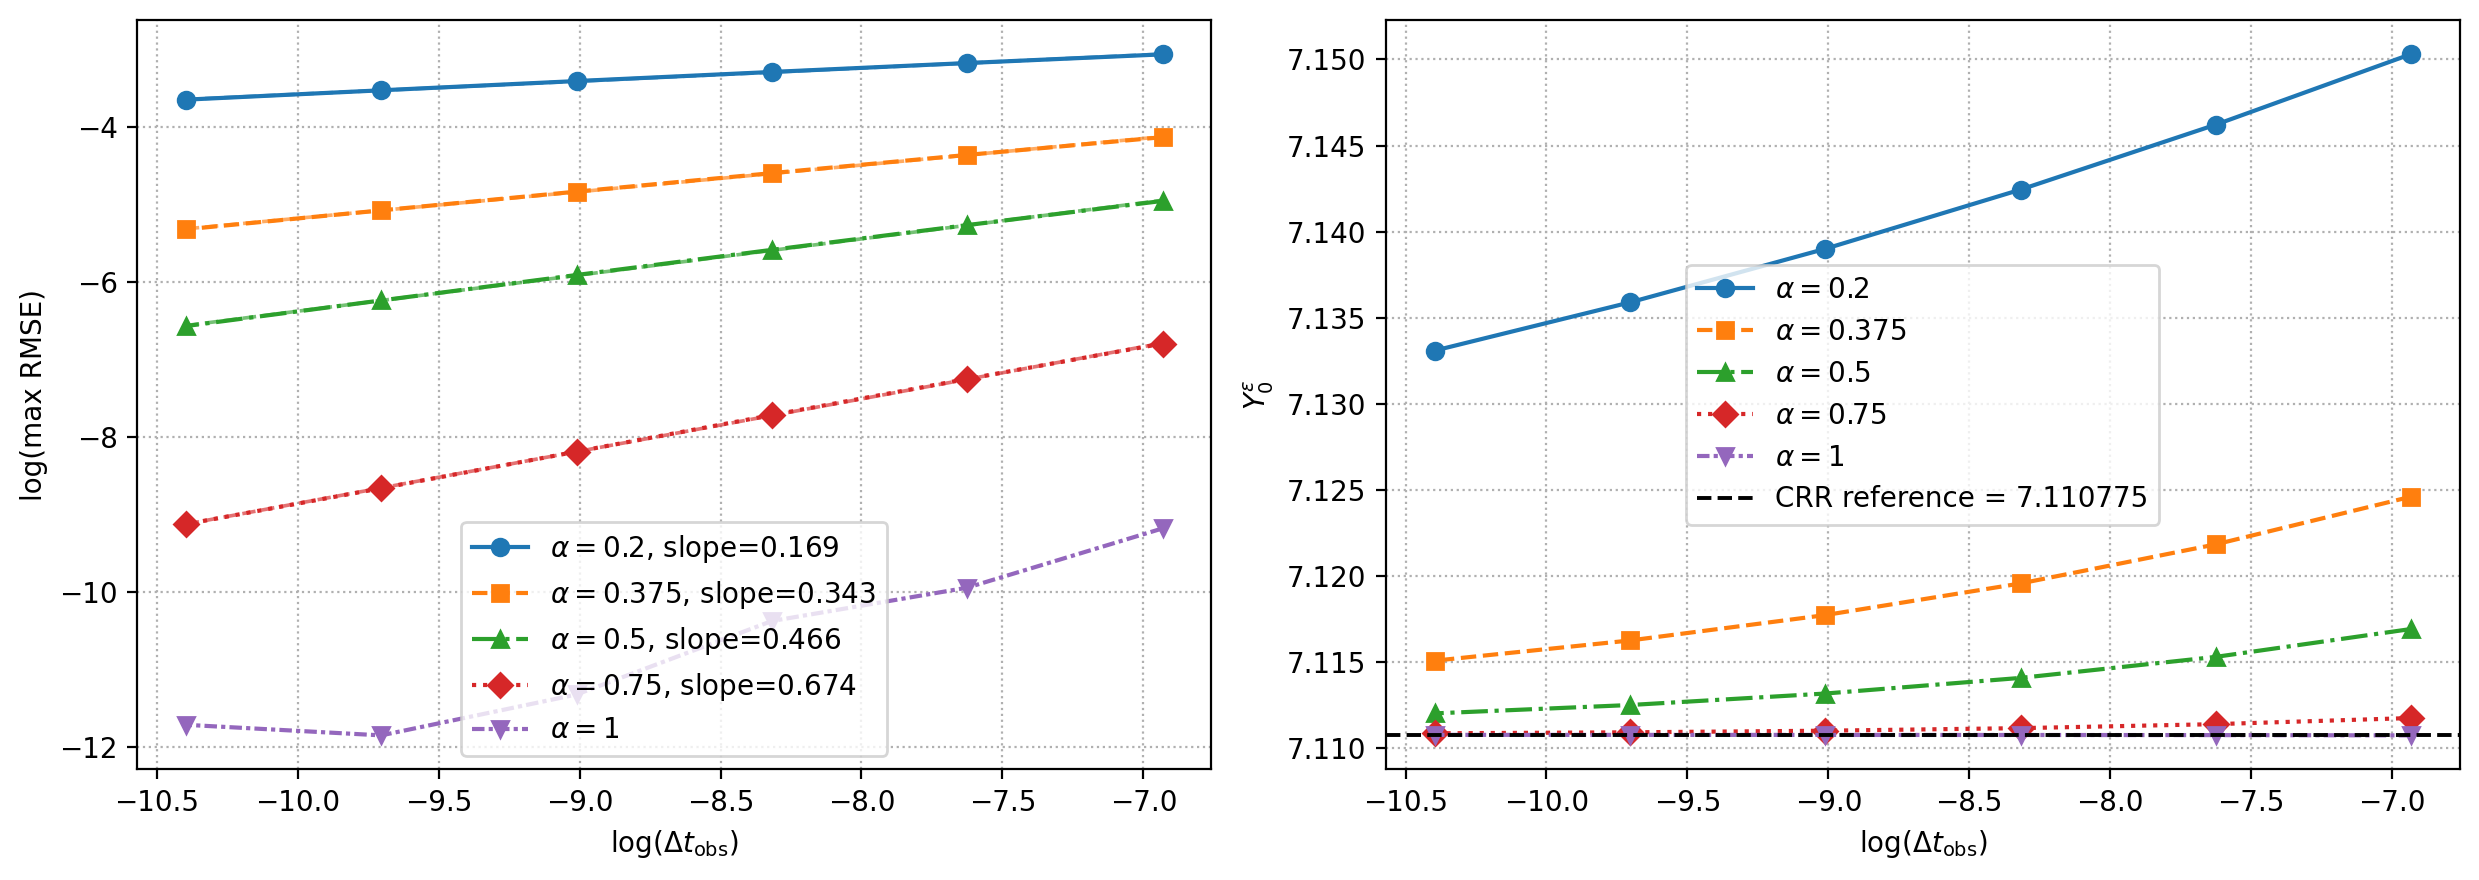

(<Figure size 2500x900 with 2 Axes>,
 array([<Axes: xlabel='$\\log(\\Delta t_{\\mathrm{obs}})$', ylabel='log(max RMSE)'>,
        <Axes: xlabel='$\\log(\\Delta t_{\\mathrm{obs}})$', ylabel='$Y_0^\\varepsilon$'>],
       dtype=object))

In [9]:
regularized_result = run_convergence_experiment(regularized_experiment)
plot_convergence(regularized_result)
